# Model Ensembles for Classification

**Author:** Phabel Antonio López Delgado, BSc.

This notebook explores ensemble techniques for machine learning, combining multiple base models to improve accuracy, robustness, and generalisation. It covers:

- **Voting Classifier** – hard and soft voting.
- **Random Forest** – bagging ensemble of decision trees.
- **AdaBoost** – sequential boosting with weak learners.
- **XGBoost** – efficient gradient boosting with regularisation.
- **Stacking** – meta‑ensemble with a final estimator.

**Key Techniques & Libraries:**
- `numpy`, `pandas`, `matplotlib` – data manipulation and visualisation.
- `scikit-learn` – preprocessing, cross‑validation, metrics, base classifiers, and ensemble methods.
- `xgboost` – gradient boosting implementation.
- `optuna` – hyperparameter optimisation.

**Dataset:**
Wine Quality Dataset – contains physicochemical properties and a sensory quality score. The goal is to predict wine quality (low, medium, high) from chemical attributes. The dataset is assumed to be located at `winequality.csv` in the same directory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Base classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Ensemble methods
from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# XGBoost
import xgboost as xgb

# Hyperparameter optimisation
import optuna

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All imports successful.")

All imports successful.


## 1. Data Loading and Preprocessing

We load the Wine Quality dataset, map the wine type to numeric, and transform the quality into three categories: low (0), medium (1), and high (2). We then split the data into training and test sets (80/20) with stratification, and scale the features: `StandardScaler` for most columns, `MinMaxScaler` for pH (range 0–14) using `ColumnTransformer`.

In [3]:
data = pd.read_csv('../data/winequality.csv')
type_mapping = {'white': 0, 'red': 1}
data['type'] = data['type'].map(type_mapping)
data = data.dropna()
data["quality"] = data["quality"].replace({3:0, 4:0, 5:0, 6:1, 7:2, 8:2, 9:2, 10:2})
y = data["quality"]
X = data.drop('quality', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.20, random_state=21
)

standard_cols = [col for col in X.columns if col != 'pH']
minmax_cols = ['pH']

ct = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), standard_cols),
        ('minmax', MinMaxScaler(feature_range=(0, 14)), minmax_cols)
    ],
    remainder='passthrough'
)

ct.fit(X_train)
X_train_scaled = ct.transform(X_train)
X_test_scaled = ct.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 5170
Test set size: 1293


In [4]:
def evaluate_models(models, X_test, y_test, class_names=None):
    for model in models:
        print(f"\n Evaluating {model.__class__.__name__}...")
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred, target_names=class_names))
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix: {model.__class__.__name__}")
        plt.grid(False)
        plt.show()

## 2. Random Forest with Hyperparameter Optimisation

We train a Random Forest classifier and use Optuna to find the best hyperparameters. The objective is the cross‑validated weighted F1 score (5‑fold stratified). After finding the best parameters, we evaluate the model on the test set.

In [5]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'n_jobs': -1,
    }
    model = RandomForestClassifier(random_state=42, **{k: v for k, v in params.items() if v is not None})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
    return np.mean(scores)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50, timeout=1000, show_progress_bar=True)

print("Best parameters:", study_rf.best_params)
print("Best CV F1 (weighted):", study_rf.best_value)

[I 2026-07-21 16:48:09,914] A new study created in memory with name: no-name-09f188b3-c8a4-424f-a584-01677de19853


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-21 16:48:14,183] Trial 0 finished with value: 0.683261185519088 and parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.683261185519088.
[I 2026-07-21 16:48:16,628] Trial 1 finished with value: 0.6786790846154007 and parameters: {'n_estimators': 150, 'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.683261185519088.
[I 2026-07-21 16:48:19,800] Trial 2 finished with value: 0.5814104412809622 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.683261185519088.
[I 2026-07-21 16:48:22,120] Trial 3 finished with value: 0.6495799338437613 and parameters: {'n_estimators': 150, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_

[I 2026-07-21 16:48:57,496] Trial 31 finished with value: 0.6991684328015095 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.7032056208251064.
[I 2026-07-21 16:48:59,093] Trial 32 finished with value: 0.7023942911275249 and parameters: {'n_estimators': 350, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.7032056208251064.
[I 2026-07-21 16:49:00,758] Trial 33 finished with value: 0.6971513142481955 and parameters: {'n_estimators': 350, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 22 with value: 0.7032056208251064.
[I 2026-07-21 16:49:02,737] Trial 34 finished with value: 0.6943398513143232 and parameters: {'n_estimators': 450, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 1,

              precision    recall  f1-score   support

           0       0.76      0.74      0.75       475
           1       0.65      0.73      0.69       564
           2       0.76      0.59      0.67       254

    accuracy                           0.71      1293
   macro avg       0.73      0.69      0.70      1293
weighted avg       0.71      0.71      0.71      1293



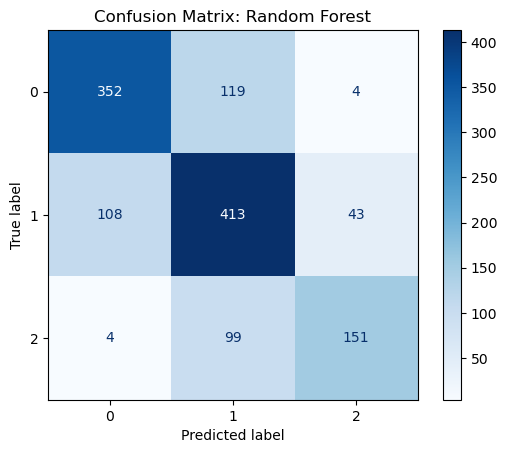

In [6]:
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Confusion Matrix: Random Forest")
plt.show()

## 3. AdaBoost with Different Weak Learners

We train AdaBoost with decision trees of varying depths (3 to 8) as weak learners, as well as logistic regression and Gaussian Naïve Bayes. We compare their test accuracy and select the best configuration for the final ensemble.

Training AdaBoost with Tree (depth=3)
Training AdaBoost with Tree (depth=4)
Training AdaBoost with Tree (depth=5)
Training AdaBoost with Tree (depth=6)
Training AdaBoost with Tree (depth=7)
Training AdaBoost with Tree (depth=8)
Training AdaBoost with Logistic Regression
Training AdaBoost with Gaussian NB


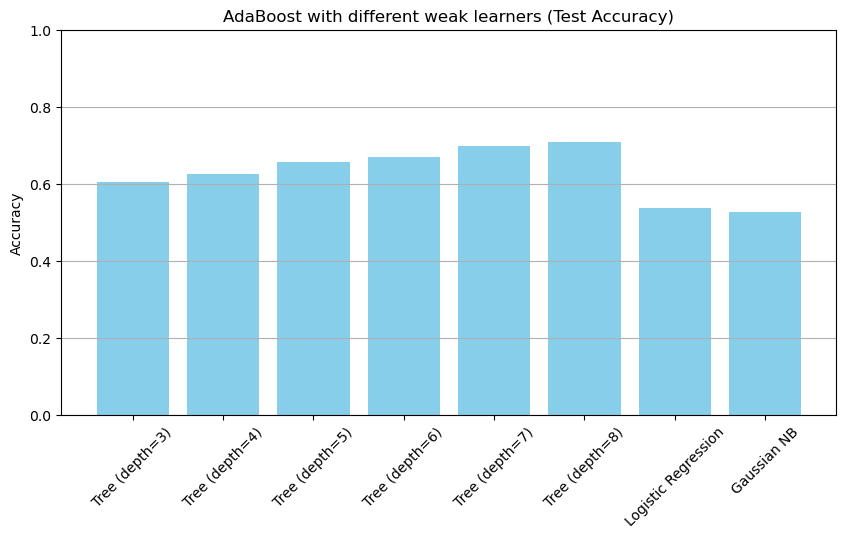

In [7]:
weak_learners = {
    "Tree (depth=3)": DecisionTreeClassifier(max_depth=3),
    "Tree (depth=4)": DecisionTreeClassifier(max_depth=4),
    "Tree (depth=5)": DecisionTreeClassifier(max_depth=5),
    "Tree (depth=6)": DecisionTreeClassifier(max_depth=6),
    "Tree (depth=7)": DecisionTreeClassifier(max_depth=7),
    "Tree (depth=8)": DecisionTreeClassifier(max_depth=8),
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Gaussian NB": GaussianNB(),
}

results = {}
for name, weak_learner in weak_learners.items():
    print(f"Training AdaBoost with {name}")
    model = AdaBoostClassifier(estimator=weak_learner, n_estimators=200, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# Plot comparison
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('AdaBoost with different weak learners (Test Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

              precision    recall  f1-score   support

           0       0.76      0.69      0.72       475
           1       0.65      0.76      0.70       564
           2       0.79      0.64      0.71       254

    accuracy                           0.71      1293
   macro avg       0.73      0.70      0.71      1293
weighted avg       0.72      0.71      0.71      1293



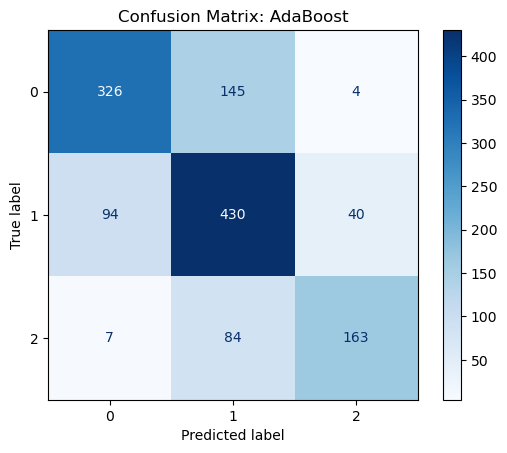

In [8]:
adaptiveboosting = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=200, random_state=42)
adaptiveboosting.fit(X_train_scaled, y_train)
y_pred_ada = adaptiveboosting.predict(X_test_scaled)
print(classification_report(y_test, y_pred_ada))

cm_ada = confusion_matrix(y_test, y_pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ada)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Confusion Matrix: AdaBoost")
plt.show()

## 4. XGBoost with Hyperparameter Optimisation

We train an XGBoost classifier and use Optuna to tune its hyperparameters. The objective is again the cross‑validated weighted F1 score.

In [9]:
def objective_xgb(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'booster': 'gbtree',
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5)
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**param, use_label_encoder=False)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted').mean()
    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)
print("Best parameters:", study_xgb.best_params)
print("Best CV F1 (weighted):", study_xgb.best_value)

[I 2026-07-21 16:51:08,882] A new study created in memory with name: no-name-7e434fa7-14c5-4542-b308-ea81bb193f3b
[I 2026-07-21 16:51:10,213] Trial 0 finished with value: 0.6034787382187219 and parameters: {'n_estimators': 109, 'max_depth': 4, 'learning_rate': 0.15089960056930432, 'subsample': 0.5421918996277467, 'colsample_bytree': 0.7188447505982094, 'gamma': 4.053582566781016, 'min_child_weight': 6, 'reg_alpha': 0.6106627446518781, 'reg_lambda': 2.0907349886119015}. Best is trial 0 with value: 0.6034787382187219.
[I 2026-07-21 16:51:12,566] Trial 1 finished with value: 0.6279226292437409 and parameters: {'n_estimators': 244, 'max_depth': 3, 'learning_rate': 0.1331906360474125, 'subsample': 0.8304327635496176, 'colsample_bytree': 0.9789962937693271, 'gamma': 1.5660607891859928, 'min_child_weight': 3, 'reg_alpha': 1.8462057719375773, 'reg_lambda': 3.5830711090012786}. Best is trial 1 with value: 0.6279226292437409.
[I 2026-07-21 16:51:18,190] Trial 2 finished with value: 0.67445205713

[I 2026-07-21 16:52:12,471] Trial 20 finished with value: 0.6098434600394012 and parameters: {'n_estimators': 225, 'max_depth': 9, 'learning_rate': 0.2173343291494061, 'subsample': 0.6818713231039473, 'colsample_bytree': 0.6243662660402882, 'gamma': 2.789474935838486, 'min_child_weight': 4, 'reg_alpha': 4.421128513154447, 'reg_lambda': 1.58569680497069}. Best is trial 15 with value: 0.6810157227926049.
[I 2026-07-21 16:52:17,095] Trial 21 finished with value: 0.672428426004201 and parameters: {'n_estimators': 186, 'max_depth': 6, 'learning_rate': 0.29823207934807733, 'subsample': 0.6216289758446595, 'colsample_bytree': 0.6444307388494588, 'gamma': 0.010499147047689894, 'min_child_weight': 4, 'reg_alpha': 4.3204765146468604, 'reg_lambda': 4.749546653730954}. Best is trial 15 with value: 0.6810157227926049.
[I 2026-07-21 16:52:19,663] Trial 22 finished with value: 0.6579942520047193 and parameters: {'n_estimators': 157, 'max_depth': 5, 'learning_rate': 0.22799005639422018, 'subsample': 0

[I 2026-07-21 16:53:31,354] Trial 40 finished with value: 0.6825238745611387 and parameters: {'n_estimators': 287, 'max_depth': 5, 'learning_rate': 0.12725617876801626, 'subsample': 0.8933561152507454, 'colsample_bytree': 0.8737005875136895, 'gamma': 0.2793560394574189, 'min_child_weight': 1, 'reg_alpha': 0.8126839669772093, 'reg_lambda': 3.581605469983801}. Best is trial 40 with value: 0.6825238745611387.
[I 2026-07-21 16:53:38,105] Trial 41 finished with value: 0.6850691559860099 and parameters: {'n_estimators': 284, 'max_depth': 5, 'learning_rate': 0.13178205697899908, 'subsample': 0.5044597541387169, 'colsample_bytree': 0.8773505183868804, 'gamma': 0.2152673117360791, 'min_child_weight': 1, 'reg_alpha': 0.5106258032264288, 'reg_lambda': 3.4863576681657817}. Best is trial 41 with value: 0.6850691559860099.
[I 2026-07-21 16:53:42,862] Trial 42 finished with value: 0.665648288302845 and parameters: {'n_estimators': 288, 'max_depth': 5, 'learning_rate': 0.06725988064556479, 'subsample'

Best parameters: {'n_estimators': 285, 'max_depth': 6, 'learning_rate': 0.12911799383630918, 'subsample': 0.8562116687795246, 'colsample_bytree': 0.8631871114636422, 'gamma': 0.22770893246148902, 'min_child_weight': 2, 'reg_alpha': 0.7614449618346222, 'reg_lambda': 0.28058320073259235}
Best CV F1 (weighted): 0.6955184690926572


              precision    recall  f1-score   support

           0       0.73      0.75      0.74       475
           1       0.65      0.69      0.67       564
           2       0.72      0.60      0.66       254

    accuracy                           0.69      1293
   macro avg       0.70      0.68      0.69      1293
weighted avg       0.69      0.69      0.69      1293



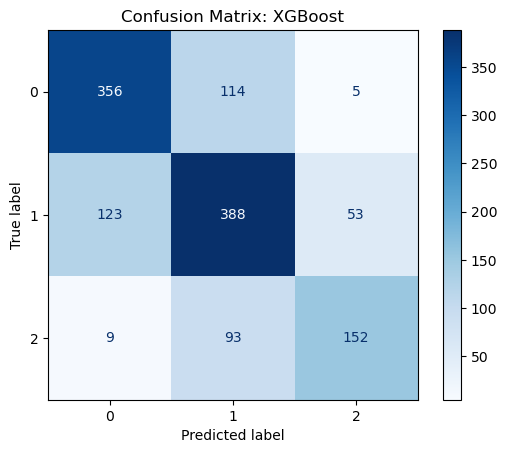

In [10]:
xgboost_model = xgb.XGBClassifier(**study_xgb.best_params)
xgboost_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgboost_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Confusion Matrix: XGBoost")
plt.show()

## 5. Voting Ensemble

We combine the three trained models (Random Forest, AdaBoost, XGBoost) using both hard and soft voting. We evaluate both versions.


 Evaluating VotingClassifier...
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       475
           1       0.66      0.73      0.69       564
           2       0.78      0.63      0.70       254

    accuracy                           0.71      1293
   macro avg       0.73      0.70      0.71      1293
weighted avg       0.71      0.71      0.71      1293



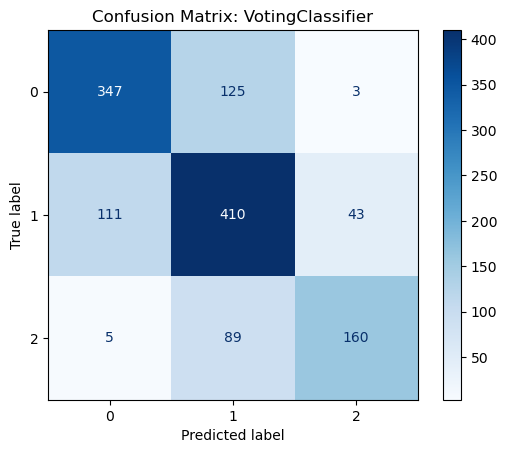


 Evaluating VotingClassifier...
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       475
           1       0.65      0.72      0.68       564
           2       0.76      0.60      0.67       254

    accuracy                           0.70      1293
   macro avg       0.72      0.69      0.70      1293
weighted avg       0.71      0.70      0.70      1293



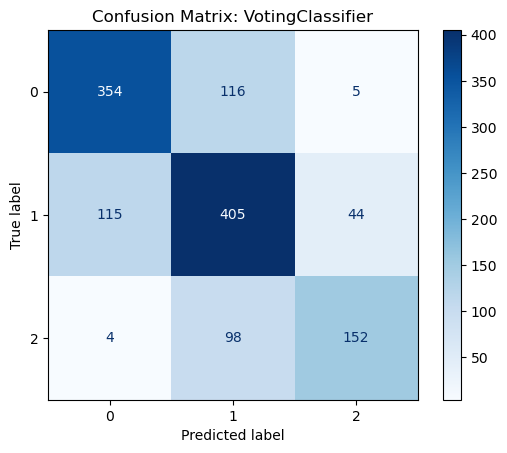

In [11]:
estimators = [('RandomForest', rf), ('AdaBoost', adaptiveboosting), ('XGBoost', xgboost_model)]

voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_soft = VotingClassifier(estimators=estimators, voting='soft')

voting_hard.fit(X_train_scaled, y_train)
voting_soft.fit(X_train_scaled, y_train)

evaluate_models([voting_hard, voting_soft], X_test_scaled, y_test)

## 6. Stacking Ensemble (Meta‑Ensemble)

We build a stacking classifier with the same three base models and a logistic regression as the meta‑learner. We also test a multi‑layer perceptron as the meta‑learner. Both use 5‑fold cross‑validation for training the base models on the meta‑features.

Stacking with Logistic Regression:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       475
           1       0.67      0.72      0.69       564
           2       0.76      0.65      0.70       254

    accuracy                           0.71      1293
   macro avg       0.73      0.70      0.71      1293
weighted avg       0.72      0.71      0.71      1293



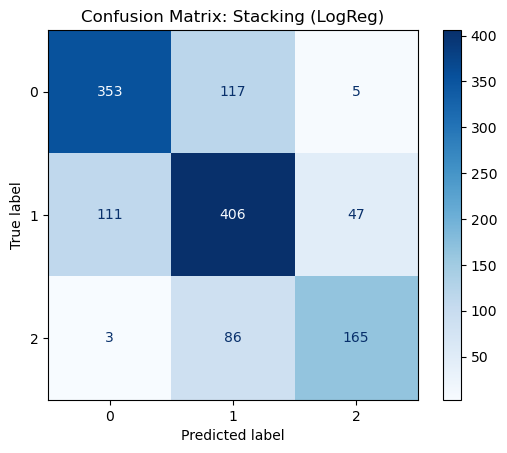

In [12]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacking_lr = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=stratified_cv,
    stack_method='predict_proba',
    passthrough=False
)
stacking_lr.fit(X_train_scaled, y_train)
y_pred_stack_lr = stacking_lr.predict(X_test_scaled)
print("Stacking with Logistic Regression:")
print(classification_report(y_test, y_pred_stack_lr))

cm_stack_lr = confusion_matrix(y_test, y_pred_stack_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack_lr)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Confusion Matrix: Stacking (LogReg)")
plt.show()

Stacking with MLP:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       475
           1       0.67      0.70      0.69       564
           2       0.74      0.67      0.70       254

    accuracy                           0.71      1293
   macro avg       0.72      0.71      0.71      1293
weighted avg       0.71      0.71      0.71      1293



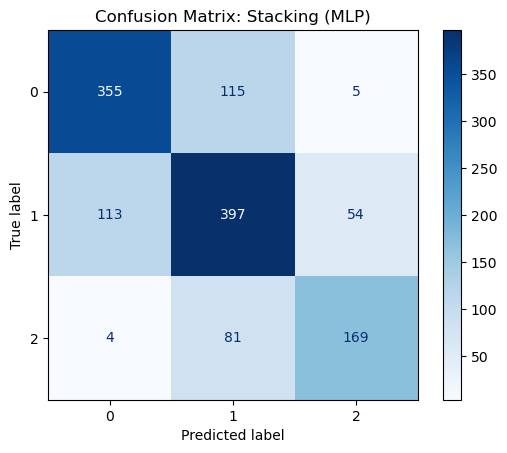

In [13]:
stacking_mlp = StackingClassifier(
    estimators=estimators,
    final_estimator=MLPClassifier(random_state=42, max_iter=300),
    cv=stratified_cv,
    stack_method='predict_proba',
    passthrough=False
)
stacking_mlp.fit(X_train_scaled, y_train)
y_pred_stack_mlp = stacking_mlp.predict(X_test_scaled)
print("Stacking with MLP:")
print(classification_report(y_test, y_pred_stack_mlp))

cm_stack_mlp = confusion_matrix(y_test, y_pred_stack_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack_mlp)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Confusion Matrix: Stacking (MLP)")
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented and compared several ensemble methods on the Wine Quality dataset.
- **Random Forest** – optimised with Optuna (50 trials); achieved a weighted F1 of **0.71** on the test set.
- **AdaBoost** – evaluated multiple weak learners; best was a decision tree of depth 8, achieving a weighted F1 of **0.71**.
- **XGBoost** – optimised with Optuna (50 trials); achieved a weighted F1 of **0.69**.
- **Voting Ensemble** – hard and soft voting combined the three models; hard voting scored **0.71**, soft voting scored **0.70**.
- **Stacking** – with logistic regression and MLP as meta‑learners; both achieved **0.71** weighted F1, similar to voting.

**Key Results (Weighted F1 on Test Set):**

| Model                    | Weighted F1 |
|--------------------------|-------------|
| Random Forest            | 0.71        |
| AdaBoost (depth=8)       | 0.71        |
| XGBoost                  | 0.69        |
| Voting (Hard)            | 0.71        |
| Voting (Soft)            | 0.70        |
| Stacking (LogReg)        | 0.71        |
| Stacking (MLP)           | 0.71        |

*Note:* All scores are from the test set. The best performing models are AdaBoost, hard voting, and both stacking variants, all with F1=0.71.

**Key Insights:**
- AdaBoost with a moderately deep tree (depth=8) performed as well as the more complex ensembles, indicating that boosting is particularly effective on this dataset.
- Voting and stacking did not significantly outperform the best individual model, suggesting that the base models may be correlated or that the ensemble gains are modest.
- Hyperparameter tuning with Optuna improved Random Forest and XGBoost, but the gains over default settings were moderate.
- Hard voting slightly outperformed soft voting in this case, possibly due to better calibration of the individual models.

**Suggested Next Steps:**
1. **Include more diverse base models** – e.g., SVM, k‑NN, CatBoost, LightGBM – to increase model diversity and potentially boost ensemble performance.
2. **Optimise the meta‑model** in stacking – tune hyperparameters of the final estimator (LogisticRegression, MLP) via grid search or Optuna.
3. **Feature engineering** – create interaction terms or domain‑specific features to improve individual model performance.
4. **Test on other datasets** – evaluate the ensemble methods on a more complex problem (e.g., larger class imbalance, higher dimensionality) to see if gains are larger.
5. **Use probability calibration** – calibrate base models before soft voting or stacking to improve soft voting results.
6. **Implement a custom weighted voting ensemble** – assign weights based on cross‑validated scores to possibly outperform hard voting.
7. **Experiment with different stacking configurations** – try `passthrough=True` to include original features, or use different meta‑learners like GradientBoosting.

**Reflection:**
This notebook provided a practical tour of modern ensemble techniques – bagging (Random Forest), boosting (AdaBoost, XGBoost), voting, and stacking. The results showed that while ensembles often improve over single models, the benefit depends on the diversity and strength of the base learners. In this case, AdaBoost and voting produced the best results, demonstrating that even simple combinations can be effective. The integration of hyperparameter optimisation with Optuna was seamless and allowed for efficient tuning of complex models. The evaluation framework using classification reports and confusion matrices enabled clear comparison across methods, making it easy to identify the best performers.